# Document Pattern Detection

This notebook demonstrates `FormulaSearch.detect_document_patterns`, which detects how a set of candidate formulaic phrases co-occur across a long text stream and groups them into communities of phrases that tend to occur together &mdash; an empirically derived signature of a document type.

This addresses a specific use case: text streams (e.g. scanned books containing hundreds of pages of resolutions, deeds, or letters) where document boundaries are not known in advance. Rather than relying on document boundaries, the pipeline scans the continuous token stream and counts how often pairs of known/candidate formulas occur within a configurable distance of each other. Phrases that habitually co-occur are connected in a weighted graph, and community detection on that graph reveals groups of phrases that signal the same recurring document type.

We'll use a small synthetic corpus with three distinct "document types", each with its own opening and closing formula, so the expected result is easy to verify.

In [1]:
%reload_ext autoreload
%autoreload 2

import random

import matplotlib.pyplot as plt
import networkx as nx

from formula_detection.search import FormulaSearch
from formula_detection.context import PhraseContext

## 1. Building a synthetic multi-document-type text stream

We generate 80 short "documents", each randomly assigned one of three types (`alpha`, `beta`, `gamma`). Every document consists of an opening formula, a stretch of random filler words, and a matching closing formula. The documents are concatenated into a single flat token stream with **no boundary markers** &mdash; exactly the situation this pipeline is designed for.

In [2]:
random.seed(42)

FORMULAS = {
    'alpha': ('opening formula alpha', 'closing formula alpha'),
    'beta': ('opening formula beta', 'closing formula beta'),
    'gamma': ('opening formula gamma', 'closing formula gamma'),
}
FILLER_WORDS = [
    'de', 'het', 'een', 'van', 'aan', 'in', 'op', 'dat', 'die', 'heeft',
    'wordt', 'wij', 'zij', 'vergadering', 'besluit', 'voorstel',
    'commissie', 'rapport', 'brief', 'verzoek', 'akkoord',
]


def make_document(doc_type: str) -> list:
    opening, closing = FORMULAS[doc_type]
    filler_len = random.randint(8, 15)
    filler = [random.choice(FILLER_WORDS) for _ in range(filler_len)]
    return opening.split() + filler + closing.split()


doc_types = random.choices(list(FORMULAS.keys()), k=80)
documents = [make_document(t) for t in doc_types]

print(f"Generated {len(documents)} documents, {sum(len(d) for d in documents)} tokens total.")
print('First document (type', doc_types[0], '):', ' '.join(documents[0]))

Generated 80 documents, 1391 tokens total.
First document (type beta ): opening formula beta brief vergadering brief zij wij dat aan commissie voorstel een het van closing formula beta


## 2. Initializing FormulaSearch

`FormulaSearch` accepts any iterable of documents (here, a plain list of token lists). Because `detect_document_patterns` re-reads the corpus from the start to scan for phrase co-occurrences, the iterable needs to be restartable &mdash; a plain list already satisfies this. For very large corpora that don't fit in memory, wrap your on-disk reader in a small class with an `__iter__` method instead.

In [3]:
formula_search = FormulaSearch(documents, min_term_freq=1)

1. Iterating over sentences to calculate term frequencies
    full collection size (tokens): 1,391
    full lexicon size (types): 27
    minimum term frequency: 1
    minimum frequency lexicon size: 27


## 3. Defining candidate formulaic phrases

In practice these candidates would come from `extract_phrases` or from a list of known partial formulas you already have for your corpus. Here we use the six formulas we generated the corpus with, so the expected grouping is easy to check.

In [4]:
candidate_phrases = [
    'opening formula alpha', 'closing formula alpha',
    'opening formula beta', 'closing formula beta',
    'opening formula gamma', 'closing formula gamma',
]

## 4. Building a PhraseContext (optional, enables phrase clustering)

`detect_document_patterns` can also run Goal 2 (semantic clustering of phrases) when given a `PhraseContext`. This needs sentences in `{'words': [...]}` form, distinct from the flat token lists `FormulaSearch` itself consumes &mdash; both views are built from the same underlying documents.

In [5]:
sentences_for_context = [{'words': doc} for doc in documents]

phrase_context = PhraseContext(candidate_phrases, sentences=sentences_for_context)
phrase_context.count_phrase_contexts()

## 5. Running the pattern-detection pipeline

`detect_document_patterns` chains together:

1. **Variant detection** (Goal 1) &mdash; skipped here since we passed no `spelling_normaliser` or `function_words`.
2. **Phrase clustering** (Goal 2) &mdash; runs because we supplied `phrase_context`.
3. **Phrase co-occurrence + community detection** (Goal 3) &mdash; always runs. It flattens the corpus into one token stream, counts how often each pair of candidate phrases occurs within `cooc_windows` tokens of each other, builds a weighted graph at `community_window`, and partitions it with Louvain community detection.

Two windows are configured: a short one (15 tokens, comparable to the typical opening&ndash;closing distance within one document) used for both co-occurrence counting and community detection, and a long one (1000 tokens) for reference. `min_llr` filters out weak, spurious associations before community detection runs.

In [6]:
result = formula_search.detect_document_patterns(
    candidate_phrases,
    cooc_windows=[15, 1000],
    community_window=15,
    min_llr=5.0,
    phrase_context=phrase_context,
)

result.keys()

dict_keys(['variant_index', 'phrase_clusters', 'cooc_index', 'phrase_graph', 'community_map', 'phrase_variant_map'])

## 6. Inspecting the results

In [7]:
cooc_index = result['cooc_index']
print('Phrase frequencies in the stream:')
for phrase, freq in cooc_index.phrase_freq.most_common():
    print(f'  {phrase: <25}{freq}')

Phrase frequencies in the stream:
  opening formula alpha    32
  closing formula alpha    32
  opening formula beta     25
  closing formula beta     25
  opening formula gamma    23
  closing formula gamma    23


In [8]:
print('Community map (phrase -> community id):')
for phrase, community_id in sorted(result['community_map'].items(), key=lambda x: x[1]):
    print(f'  community {community_id}: {phrase}')

Community map (phrase -> community id):
  community 0: closing formula alpha
  community 0: opening formula alpha
  community 1: closing formula gamma
  community 1: opening formula gamma
  community 2: closing formula beta
  community 2: opening formula beta


Each of the three document types (`alpha`, `beta`, `gamma`) forms its own community containing exactly its opening and closing formula &mdash; recovered purely from co-occurrence statistics in the flat token stream, with no document boundaries ever supplied to the pipeline.

## 7. Visualising the phrase co-occurrence graph

Nodes are candidate phrases; edge weights are log-likelihood-ratio (LLR) association scores. Node colour encodes the community assignment, so phrases that signal the same document type are visually grouped together.

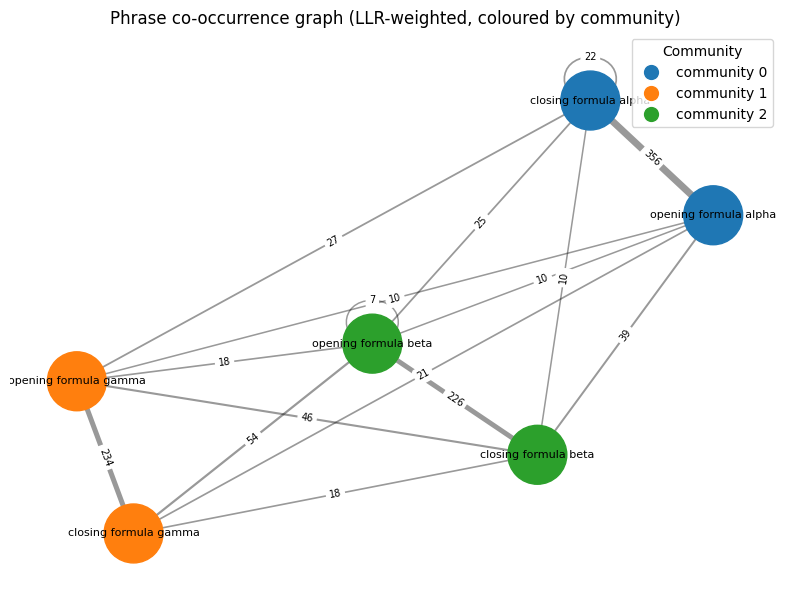

In [9]:
graph = result['phrase_graph']
community_map = result['community_map']

fig, ax = plt.subplots(figsize=(8, 6))

pos = nx.spring_layout(graph, seed=42, k=1.2)

communities = sorted(set(community_map.values()))
cmap = plt.get_cmap('tab10')
community_colors = {c: cmap(i % 10) for i, c in enumerate(communities)}
node_colors = [community_colors[community_map[n]] for n in graph.nodes()]

weights = [graph[u][v]['weight'] for u, v in graph.edges()]
max_weight = max(weights) if weights else 1.0
edge_widths = [1 + 4 * (w / max_weight) for w in weights]

nx.draw_networkx_edges(graph, pos, width=edge_widths, alpha=0.4, ax=ax)
nx.draw_networkx_nodes(graph, pos, node_color=node_colors, node_size=1800, ax=ax)
nx.draw_networkx_labels(graph, pos, font_size=8, ax=ax)

edge_labels = {(u, v): f"{graph[u][v]['weight']:.0f}" for u, v in graph.edges()}
nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=7, ax=ax)

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=community_colors[c],
               markersize=12, label=f'community {c}')
    for c in communities
]
ax.legend(handles=legend_handles, loc='upper right', title='Community')
ax.set_title('Phrase co-occurrence graph (LLR-weighted, coloured by community)')
ax.axis('off')
plt.tight_layout()
plt.show()

## 8. Comparing to phrase clusters (Goal 2)

Since we also supplied `phrase_context`, `detect_document_patterns` ran semantic clustering on the same phrases based on their surrounding context words. With this corpus there's not enough distinct context vocabulary to fully separate clusters as cleanly as the co-occurrence communities, but the result is available for inspection and grows more informative with richer, larger corpora.

In [10]:
phrase_clusters = result['phrase_clusters']
if phrase_clusters is not None:
    print(phrase_clusters)
    for cluster_id in sorted(phrase_clusters.cluster_to_phrases):
        print(f'  cluster {cluster_id}: {phrase_clusters.phrases_in(cluster_id)}')
else:
    print('No phrase_clusters produced (e.g. no context vocabulary found).')

PhraseClusters(n_clusters=4, n_phrases=6)
  cluster 0: ['closing formula alpha', 'closing formula gamma']
  cluster 1: ['opening formula gamma']
  cluster 2: ['opening formula alpha', 'closing formula beta']
  cluster 3: ['opening formula beta']


## Next steps

* For a real corpus, replace `candidate_phrases` with output from `FormulaSearch.extract_phrases` or with your own curated list of known partial formulas.
* Pass `function_words` and/or `spelling_normaliser` to `detect_document_patterns` to enable orthographic variant detection (Goal 1) before clustering and co-occurrence counting, so that spelling variants of the same formula are merged.
* `formula_detection.boundary.BoundaryDetector` builds on the `community_map` and `cooc_index` produced here to score likely document boundaries in the stream. It works best when communities correspond to a document-wide *role* (e.g. "tends to open documents" vs. "tends to close documents") rather than to document *type* as in this toy example &mdash; on a real corpus with a consistent document structure this distinction usually emerges naturally.